# EXP-PREP: Ekstraksi Raw Overlap MovieLens × Netflix

Notebook ini mengekstrak **titik awal mentah** (raw overlap) antara dataset MovieLens 25M dan Netflix.

## Tujuan

Melakukan penyelarasan (matching) film antara MovieLens dan Netflix berdasarkan judul dan tahun rilis, menyaring rating positif (suka) serta film modern (tahun rilis >= 2015), dan menyimpan hasilnya sebagai dataset overlap mentah.

## Filter yang Diterapkan (Teknis-Netral)

| Filter | Justifikasi | Sifat |
|---|---|---|
| Rating ≥ 3.5 | Batas rating "suka" | Tetap ada |
| Inner join judul + tahun | Teknis — dua dataset perlu dipadukan | Tetap ada |
| Tahun rilis ≥ 2015 | Definisi domain konten modern | Tetap ada |
| Normalisasi teks | Koreksi kualitas data (unicode, titlecase) | Tetap ada |

## Output

```
raw_overlap/
    interactions_raw.csv       ← data interaksi (user_id, show_id) hasil filter
    films_metadata_clean.csv   ← metadata film lengkap dengan kolom tags MovieLens
    raw_overlap_stats.json     ← statistik distribusi
```

In [1]:
# ══════════════════════════════════════════════════════════════════════════
# KONFIGURASI
# ══════════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import re
import json
import unicodedata
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

BASE_DIR = Path().resolve()

# ── Input Paths ────────────────────────────────────────────────────────────
RATINGS_PATH = BASE_DIR / "ml-25m" / "ratings.csv"
MOVIES_PATH  = BASE_DIR / "ml-25m" / "movies.csv"
NETFLIX_PATH = BASE_DIR / "Data_Netflix" / "netflix_titles.csv"
GENOME_SCORES_PATH = BASE_DIR / "ml-25m" / "genome-scores.csv"
GENOME_TAGS_PATH   = BASE_DIR / "ml-25m" / "genome-tags.csv"

# ── Output Paths ───────────────────────────────────────────────────────────
OUT_DIR = BASE_DIR / "raw_overlap"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_INTERACTIONS = OUT_DIR / "interactions_raw.csv"
OUT_FILMS        = OUT_DIR / "films_metadata_clean.csv"
OUT_STATS        = OUT_DIR / "raw_overlap_stats.json"

# ── Parameter Filter Teknis-Netral ────────────────────────────────────────
MIN_RATING   = 3.5     # Batas rating "suka" (domain definition)
MIN_YEAR     = 2015    # Filter konten modern (domain definition)
# TIDAK ada MIN_USER_INTERACTIONS di sini — itu adalah variabel eksperimen V1!

print("=" * 60)
print("EXP-PREP: Ekstraksi Raw Overlap MovieLens × Netflix")
print("=" * 60)
print(f"Input:")
print(f"  Ratings  : {RATINGS_PATH.exists()} — {RATINGS_PATH}")
print(f"  Movies   : {MOVIES_PATH.exists()} — {MOVIES_PATH}")
print(f"  Netflix  : {NETFLIX_PATH.exists()} — {NETFLIX_PATH}")
print(f"  Scores   : {GENOME_SCORES_PATH.exists()} — {GENOME_SCORES_PATH}")
print(f"  Tags     : {GENOME_TAGS_PATH.exists()} — {GENOME_TAGS_PATH}")
print(f"\nOutput DIR: {OUT_DIR}")
print(f"\nParameter:")
print(f"  Min Rating : {MIN_RATING}")
print(f"  Min Year   : {MIN_YEAR}")

EXP-PREP: Ekstraksi Raw Overlap MovieLens × Netflix
Input:
  Ratings  : True — D:\Prototipe-Skripsi\Preprocessing\ml-25m\ratings.csv
  Movies   : True — D:\Prototipe-Skripsi\Preprocessing\ml-25m\movies.csv
  Netflix  : True — D:\Prototipe-Skripsi\Preprocessing\Data_Netflix\netflix_titles.csv
  Scores   : True — D:\Prototipe-Skripsi\Preprocessing\ml-25m\genome-scores.csv
  Tags     : True — D:\Prototipe-Skripsi\Preprocessing\ml-25m\genome-tags.csv

Output DIR: D:\Prototipe-Skripsi\Preprocessing\raw_overlap

Parameter:
  Min Rating : 3.5
  Min Year   : 2015


In [2]:
# ══════════════════════════════════════════════════════════════════════════
# FUNGSI HELPER
# ══════════════════════════════════════════════════════════════════════════

def normalize_ml_title(title: str):
    """Normalisasi judul MovieLens → (judul_clean, tahun)."""
    title = str(title).strip().strip('"')
    year_match = re.search(r'\((\d{4})\)\s*$', title)
    year = year_match.group(1) if year_match else None
    title = re.sub(r'\s*\(\d{4}\)\s*$', '', title).strip()
    # "Title, The" → "The Title"
    m = re.match(r'^(.*),\s*(The|A|An)\s*$', title, re.IGNORECASE)
    if m:
        title = f"{m.group(2)} {m.group(1)}"
    return re.sub(r'\s+', ' ', title).strip().lower(), year


def normalize_netflix_title(title: str) -> str:
    """Normalisasi judul Netflix → judul_clean."""
    return re.sub(r'\s+', ' ', str(title).strip()).strip().lower()


def apply_nfc(series: pd.Series) -> pd.Series:
    """Normalisasi unicode NFC pada Series string."""
    return series.apply(
        lambda x: unicodedata.normalize("NFC", x) if isinstance(x, str) else x
    )


def apply_titlecase_multivalue(series: pd.Series) -> pd.Series:
    """Title-case untuk kolom multi-nilai (dipisah koma)."""
    def _fix(val):
        if not isinstance(val, str):
            return val
        return ", ".join([p.strip().title() for p in val.split(",") if p.strip()])
    return series.apply(_fix)


# Pattern untuk mendeteksi rating tidak valid (misal: "74 min", "66 min")
INVALID_RATING_PATTERN = re.compile(r'^\d+\s*(min|seasons?)$', re.IGNORECASE)

In [3]:
# ══════════════════════════════════════════════════════════════════════════
# STEP 1: Filter Rating Positif dari MovieLens
# ══════════════════════════════════════════════════════════════════════════
print(f"STEP 1: Filter rating MovieLens ≥ {MIN_RATING}")
print("  (Memuat ratings.csv — proses ini ~30 detik karena file besar)")

ratings = pd.read_csv(RATINGS_PATH, usecols=['userId', 'movieId', 'rating'])
print(f"  Total rating dimuat: {len(ratings):,}")

liked = ratings[ratings['rating'] >= MIN_RATING][['userId', 'movieId']].copy()
liked = liked.drop_duplicates()  # hapus duplikat jika user memberi rating berkali-kali

print(f"  Rating ≥ {MIN_RATING} (positif)  : {len(liked):,}")
print(f"  User unik              : {liked['userId'].nunique():,}")
print(f"  Film unik (movieId)    : {liked['movieId'].nunique():,}")

del ratings  # bebaskan memori
print("\n✅ STEP 1 selesai.")

STEP 1: Filter rating MovieLens ≥ 3.5
  (Memuat ratings.csv — proses ini ~30 detik karena file besar)
  Total rating dimuat: 25,000,095
  Rating ≥ 3.5 (positif)  : 15,630,129
  User unik              : 162,414
  Film unik (movieId)    : 47,396

✅ STEP 1 selesai.


In [4]:
# ══════════════════════════════════════════════════════════════════════════
# STEP 2: Normalisasi Judul MovieLens
# ══════════════════════════════════════════════════════════════════════════
print("STEP 2: Normalisasi judul MovieLens")

movies = pd.read_csv(MOVIES_PATH)
norm = movies['title'].apply(normalize_ml_title)
movies['title_clean'] = norm.apply(lambda x: x[0])
movies['year'] = pd.to_numeric(norm.apply(lambda x: x[1]), errors='coerce')

print(f"  Film MovieLens dimuat: {len(movies):,}")
print(f"  Contoh normalisasi:")
sample_norm = movies[['title', 'title_clean', 'year']].dropna().head(5)
print(sample_norm.to_string(index=False))
print("\n✅ STEP 2 selesai.")

STEP 2: Normalisasi judul MovieLens
  Film MovieLens dimuat: 62,423
  Contoh normalisasi:
                             title                 title_clean   year
                  Toy Story (1995)                   toy story 1995.0
                    Jumanji (1995)                     jumanji 1995.0
           Grumpier Old Men (1995)            grumpier old men 1995.0
          Waiting to Exhale (1995)           waiting to exhale 1995.0
Father of the Bride Part II (1995) father of the bride part ii 1995.0

✅ STEP 2 selesai.


In [5]:
# ══════════════════════════════════════════════════════════════════════════
# STEP 3: Normalisasi Judul Netflix
# ══════════════════════════════════════════════════════════════════════════
print("STEP 3: Normalisasi judul Netflix")

netflix = pd.read_csv(NETFLIX_PATH)
print(f"  Film Netflix dimuat: {len(netflix):,} baris")
print(f"  Kolom: {list(netflix.columns)}")

netflix['title_clean'] = netflix['title'].apply(normalize_netflix_title)
netflix['year'] = pd.to_numeric(netflix['release_year'], errors='coerce')

print(f"\n  Contoh normalisasi:")
print(netflix[['title', 'title_clean', 'year']].head(5).to_string(index=False))
print("\n✅ STEP 3 selesai.")

STEP 3: Normalisasi judul Netflix
  Film Netflix dimuat: 8,807 baris
  Kolom: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

  Contoh normalisasi:
                title           title_clean  year
 Dick Johnson Is Dead  dick johnson is dead  2020
        Blood & Water         blood & water  2021
            Ganglands             ganglands  2021
Jailbirds New Orleans jailbirds new orleans  2021
         Kota Factory          kota factory  2021

✅ STEP 3 selesai.


In [6]:
# ══════════════════════════════════════════════════════════════════════════
# STEP 4: Inner Join Judul + Tahun, Filter Tahun ≥ 2015
# ══════════════════════════════════════════════════════════════════════════
print(f"STEP 4: Pencocokan film MovieLens × Netflix (judul + tahun ≥ {MIN_YEAR})")

matched = pd.merge(
    movies[['movieId', 'title_clean', 'year']],
    netflix[['show_id', 'title_clean', 'year']],
    on=['title_clean', 'year'],
    how='inner'
)

# Filter tahun modern
matched = matched[matched['year'] >= MIN_YEAR]
matched = matched.drop_duplicates(subset=['movieId', 'show_id'])

print(f"  Film berhasil dicocokkan: {len(matched):,}")
print(f"  Rentang tahun: {int(matched['year'].min())} – {int(matched['year'].max())}")

# Gabungkan dengan interaksi positif
print(f"\n  Menggabungkan dengan interaksi rating...")
interactions = pd.merge(
    liked,
    matched[['movieId', 'show_id']],
    on='movieId',
    how='inner'
)
interactions = interactions[['userId', 'show_id']].drop_duplicates().sort_values(['userId', 'show_id'])
interactions = interactions.rename(columns={'userId': 'user_id'})

print(f"  Interaksi (user, film) : {len(interactions):,}")
print(f"  User unik              : {interactions['user_id'].nunique():,}")
print(f"  Film unik (show_id)    : {interactions['show_id'].nunique():,}")
print("\n✅ STEP 4 selesai.")

STEP 4: Pencocokan film MovieLens × Netflix (judul + tahun ≥ 2015)
  Film berhasil dicocokkan: 1,473
  Rentang tahun: 2015 – 2019

  Menggabungkan dengan interaksi rating...
  Interaksi (user, film) : 101,633
  User unik              : 23,432
  Film unik (show_id)    : 1,301

✅ STEP 4 selesai.


In [7]:
# ══════════════════════════════════════════════════════════════════════════
# STEP 5: Normalisasi Metadata Film Netflix & Penambahan Tag MovieLens
# Kolom yang dipertahankan: show_id, title, director, cast, country, rating, listed_in, release_year, tags
# ══════════════════════════════════════════════════════════════════════════
print("STEP 5: Normalisasi metadata film Netflix & Penambahan Tag MovieLens")

# Ambil hanya film yang masuk ke interaksi
valid_show_ids = set(interactions['show_id'])
df_film = netflix[netflix['show_id'].isin(valid_show_ids)].copy()
print(f"  Film dengan interaksi: {len(df_film):,}")

# --- Penambahan Tag Genome dari MovieLens (relevance >= 0.8) ---
print("  Memuat data tag genome MovieLens...")
show2movie = dict(zip(matched['show_id'], matched['movieId']))
mapped_movie_ids = set(matched['movieId'])

# Memuat genome-scores.csv secara chunked untuk hemat RAM
chunks = []
for chunk in pd.read_csv(GENOME_SCORES_PATH, chunksize=1_000_000):
    filtered_chunk = chunk[
        (chunk['movieId'].isin(mapped_movie_ids)) & (chunk['relevance'] >= 0.7)
    ]
    chunks.append(filtered_chunk)
df_scores = pd.concat(chunks)

# Gabungkan dengan genome-tags untuk mendapatkan nama tag
df_tags = pd.read_csv(GENOME_TAGS_PATH)
df_scores = pd.merge(df_scores, df_tags, on='tagId', how='inner')

# Kelompokkan tag per movieId dan gabungkan menjadi string dipisahkan koma
df_movie_tags = df_scores.groupby('movieId')['tag'].apply(lambda x: ', '.join(sorted(x.unique()))).reset_index()
movie2tags = dict(zip(df_movie_tags['movieId'], df_movie_tags['tag']))

# Petakan ke show_id di df_film
df_film['movieId'] = df_film['show_id'].map(show2movie)
df_film['tags'] = df_film['movieId'].map(movie2tags)
df_film = df_film.drop(columns=['movieId'])

# Pilih kolom yang relevan untuk KG (termasuk kolom tags baru)
SELECTED_COLS = ['show_id', 'title', 'director', 'cast', 'country', 'rating', 'listed_in', 'release_year', 'tags']
df_film = df_film[SELECTED_COLS].copy()

# Bersihkan nilai NaN (kolom tags juga akan ikut dibersihkan dan jika NaN diganti np.nan)
for col in df_film.columns:
    if df_film[col].dtype == object:
        df_film[col] = df_film[col].astype(str).str.strip().replace('nan', np.nan)

# B1. Unicode NFC pada cast, director, title
NFC_COLS = ['cast', 'director', 'title']
for col in NFC_COLS:
    if col in df_film.columns:
        df_film[col] = apply_nfc(df_film[col])

# B2. Title-case pada cast, director
TITLECASE_COLS = ['cast', 'director']
for col in TITLECASE_COLS:
    if col in df_film.columns:
        df_film[col] = apply_titlecase_multivalue(df_film[col])

# B3. Perbaiki rating tidak valid (misal: "74 min" → NaN)
if 'rating' in df_film.columns:
    is_invalid = df_film['rating'].str.match(INVALID_RATING_PATTERN, na=False)
    n_invalid = is_invalid.sum()
    if n_invalid > 0:
        print(f"  Rating tidak valid ditemukan: {n_invalid} baris → diset NaN")
        print(f"    Contoh: {df_film.loc[is_invalid, 'rating'].unique()[:5]}")
        df_film.loc[is_invalid, 'rating'] = np.nan
    else:
        print(f"  Rating tidak valid: 0 baris (semua valid)")

# B4. Hapus baris yang semua kolom relasi kosong (film tanpa metadata)
# Catatan: tags tidak dijadikan prasyarat kolom relasi utama agar tidak merusak filtering baris
RELATION_COLS = ['director', 'cast', 'country', 'rating', 'listed_in']
mask_all_null = df_film[RELATION_COLS].isna().all(axis=1)
n_removed = mask_all_null.sum()
df_film = df_film[~mask_all_null].reset_index(drop=True)

print(f"  Baris tanpa relasi dihapus: {n_removed}")
print(f"  Film metadata bersih final: {len(df_film):,}")

# Sinkronkan interaksi dengan film yang tersisa
final_show_ids = set(df_film['show_id'])
interactions_final = interactions[interactions['show_id'].isin(final_show_ids)].reset_index(drop=True)
if len(interactions_final) < len(interactions):
    print(f"  Interaksi disesuaikan: {len(interactions)} → {len(interactions_final)} (karena beberapa film dihapus)")

print("\n✅ STEP 5 selesai.")

STEP 5: Normalisasi metadata film Netflix & Penambahan Tag MovieLens
  Film dengan interaksi: 1,301
  Memuat data tag genome MovieLens...
  Rating tidak valid ditemukan: 2 baris → diset NaN
    Contoh: ['74 min' '66 min']
  Baris tanpa relasi dihapus: 0
  Film metadata bersih final: 1,301

✅ STEP 5 selesai.


STEP 6: Statistik distribusi raw overlap
  Total interaksi       : 101,633
  Jumlah user           : 23,432
  Jumlah film           : 1,301

  Interaksi per user:
    Rata-rata           : 4.34
    Median              : 2
    Min / Max           : 1 / 304


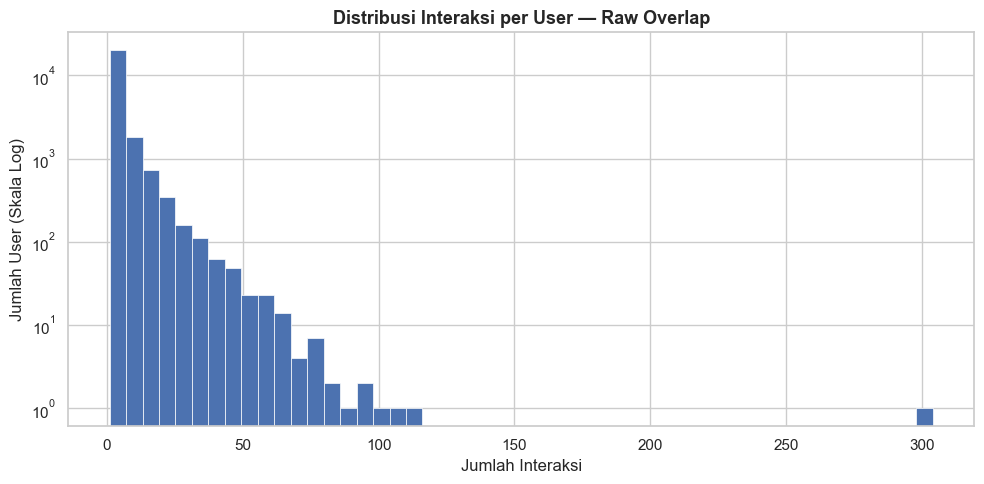


✅ Visualisasi disimpan ke: D:\Prototipe-Skripsi\Preprocessing\raw_overlap\interaction_distribution.png


In [8]:
# ══════════════════════════════════════════════════════════════════════════
# STEP 6: Statistik & Visualisasi Distribusi
# ══════════════════════════════════════════════════════════════════════════
print("STEP 6: Statistik distribusi raw overlap")
print("=" * 55)

user_counts = interactions_final['user_id'].value_counts()
film_counts = interactions_final['show_id'].value_counts()

stats = {
    "n_interactions_total": int(len(interactions_final)),
    "n_users": int(interactions_final['user_id'].nunique()),
    "n_films": int(interactions_final['show_id'].nunique()),
    "avg_interactions_per_user": float(user_counts.mean()),
    "median_interactions_per_user": float(user_counts.median()),
    "max_interactions_per_user": int(user_counts.max()),
    "min_interactions_per_user": int(user_counts.min()),
    "avg_interactions_per_film": float(film_counts.mean()),
    "median_interactions_per_film": float(film_counts.median()),
}

print(f"  Total interaksi       : {stats['n_interactions_total']:,}")
print(f"  Jumlah user           : {stats['n_users']:,}")
print(f"  Jumlah film           : {stats['n_films']:,}")
print(f"")
print(f"  Interaksi per user:")
print(f"    Rata-rata           : {stats['avg_interactions_per_user']:.2f}")
print(f"    Median              : {stats['median_interactions_per_user']:.0f}")
print(f"    Min / Max           : {stats['min_interactions_per_user']} / {stats['max_interactions_per_user']}")

# Visualisasi distribusi interaksi per user
plt.figure(figsize=(10, 5))
plt.hist(user_counts.values, bins=50, color='#4C72B0', edgecolor='white', linewidth=0.5)
plt.title("Distribusi Interaksi per User — Raw Overlap", fontweight='bold', fontsize=13)
plt.xlabel("Jumlah Interaksi")
plt.ylabel("Jumlah User (Skala Log)")
plt.yscale('log')

plt.tight_layout()
plt.savefig(OUT_DIR / "interaction_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ Visualisasi disimpan ke: {OUT_DIR / 'interaction_distribution.png'}")


In [9]:
# ══════════════════════════════════════════════════════════════════════════
# STEP 7: Simpan Output
# ══════════════════════════════════════════════════════════════════════════
print("STEP 7: Menyimpan output raw overlap...")

# 1. Interaksi mentah
interactions_final.to_csv(OUT_INTERACTIONS, index=False)
print(f"  ✅ interactions_raw.csv   → {len(interactions_final):,} baris ({interactions_final['user_id'].nunique():,} user)")

# 2. Metadata film bersih
df_film.to_csv(OUT_FILMS, index=False)
print(f"  ✅ films_metadata_clean.csv → {len(df_film):,} film")

# 3. Statistik dalam JSON
with open(OUT_STATS, 'w', encoding='utf-8') as f:
    json.dump(stats, f, indent=2)
print(f"  ✅ raw_overlap_stats.json → statistik distribusi tersimpan")

print(f"\n{'='*55}")
print(f"SELESAI! Semua file tersimpan di: {OUT_DIR}")
print(f"{'='*55}")


STEP 7: Menyimpan output raw overlap...
  ✅ interactions_raw.csv   → 101,633 baris (23,432 user)
  ✅ films_metadata_clean.csv → 1,301 film
  ✅ raw_overlap_stats.json → statistik distribusi tersimpan

SELESAI! Semua file tersimpan di: D:\Prototipe-Skripsi\Preprocessing\raw_overlap


In [10]:
# ══════════════════════════════════════════════════════════════════════════
# PREVIEW OUTPUT FILES
# ══════════════════════════════════════════════════════════════════════════
print("Preview: interactions_raw.csv (5 baris pertama)")
print(pd.read_csv(OUT_INTERACTIONS).head())

print("\nPreview: films_metadata_clean.csv (5 baris pertama)")
df_preview = pd.read_csv(OUT_FILMS)
print(df_preview.head())
print(f"\nKolom: {list(df_preview.columns)}")

print("\n📊 Missing Values per Kolom (films_metadata_clean.csv):")
missing = df_preview.isna().sum()
missing_pct = (missing / len(df_preview) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Pct (%)': missing_pct})
print(missing_df[missing_df['Missing'] > 0].to_string())

Preview: interactions_raw.csv (5 baris pertama)
   user_id show_id
0        3   s1260
1        3    s134
2        3   s6717
3        3   s6926
4        3   s7152

Preview: films_metadata_clean.csv (5 baris pertama)
  show_id                                              title  \
0     s39                                Birth of the Dragon   
1     s95                                          Show Dogs   
2     s97  If I Leave Here Tomorrow: A Film About Lynyrd ...   
3    s106                                   Angamaly Diaries   
4    s134                                            Chappie   

               director                                               cast  \
0          George Nolfi  Billy Magnussen, Ron Yuan, Qu Jingjing, Terry ...   
1          Raja Gosnell  Will Arnett, Ludacris, Natasha Lyonne, Stanley...   
2         Stephen Kijak  Ronnie Van Zandt, Gary Rossington, Allen Colli...   
3  Lijo Jose Pellissery  Antony Varghese, Reshma Rajan, Binny Rinky Ben...   
4        N